In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import healpy as hp
import astropy.io.fits as fits
from astropy.visualization import ImageNormalize,MinMaxInterval,LogStretch,ManualInterval
from scipy.stats import norm

In [3]:
# The code in this notebook reproduces Figure 6 from Nofi et al. (2025a)
# https://arxiv.org/abs/2509.03718

In [4]:
# Input cleaned maps from initial cleaning fit
initial_70_map="INITIAL_Maps/Initial_Cleaned_70GHz.fits"
initial_70=hp.fitsfunc.read_map(initial_70_map,field=[0])

initial_94_map="INITIAL_Maps/Initial_Cleaned_94GHz.fits"
initial_94=hp.fitsfunc.read_map(initial_94_map,field=[0])

initial_100_map="INITIAL_Maps/Initial_Cleaned_100GHz.fits"
initial_100=hp.fitsfunc.read_map(initial_100_map,field=[0])

initial_143_map="INITIAL_Maps/Initial_Cleaned_143GHz.fits"
initial_143=hp.fitsfunc.read_map(initial_143_map,field=[0])

In [5]:
# Masks created using procedure described in Section 3.5
# 0.5% of pixels masked
mask_05p="../ELC_Masks/ELC_0.5percent_mask.fits"
mask_05p=hp.fitsfunc.read_map(mask_05p,field=[0])

# 1% of pixels masked
mask_1p="../ELC_Masks/ELC_1percent_mask.fits"
mask_1p=hp.fitsfunc.read_map(mask_1p,field=[0])

# 2% of pixels masked
mask_2p="../ELC_Masks/ELC_2percent_mask.fits"
mask_2p=hp.fitsfunc.read_map(mask_2p,field=[0])

In [6]:
# Convert zero pixels to nans
mask_05p = mask_05p.astype(float)
mask_1p = mask_1p.astype(float)
mask_2p = mask_2p.astype(float)

mask_05p[mask_05p == 0] = np.nan
mask_1p[mask_1p == 0] = np.nan
mask_2p[mask_2p == 0] = np.nan

In [7]:
# Apply masks to initial cleaned maps
p70_mask05p = mask_05p*initial_70
p70_mask1p = mask_1p*initial_70
p70_mask2p = mask_2p*initial_70

w94_mask05p = mask_05p*initial_94
w94_mask1p = mask_1p*initial_94
w94_mask2p = mask_2p*initial_94

p100_mask05p = mask_05p*initial_100
p100_mask1p = mask_1p*initial_100
p100_mask2p = mask_2p*initial_100

p143_mask05p  = mask_05p*initial_143
p143_mask1p = mask_1p*initial_143
p143_mask2p = mask_2p*initial_143

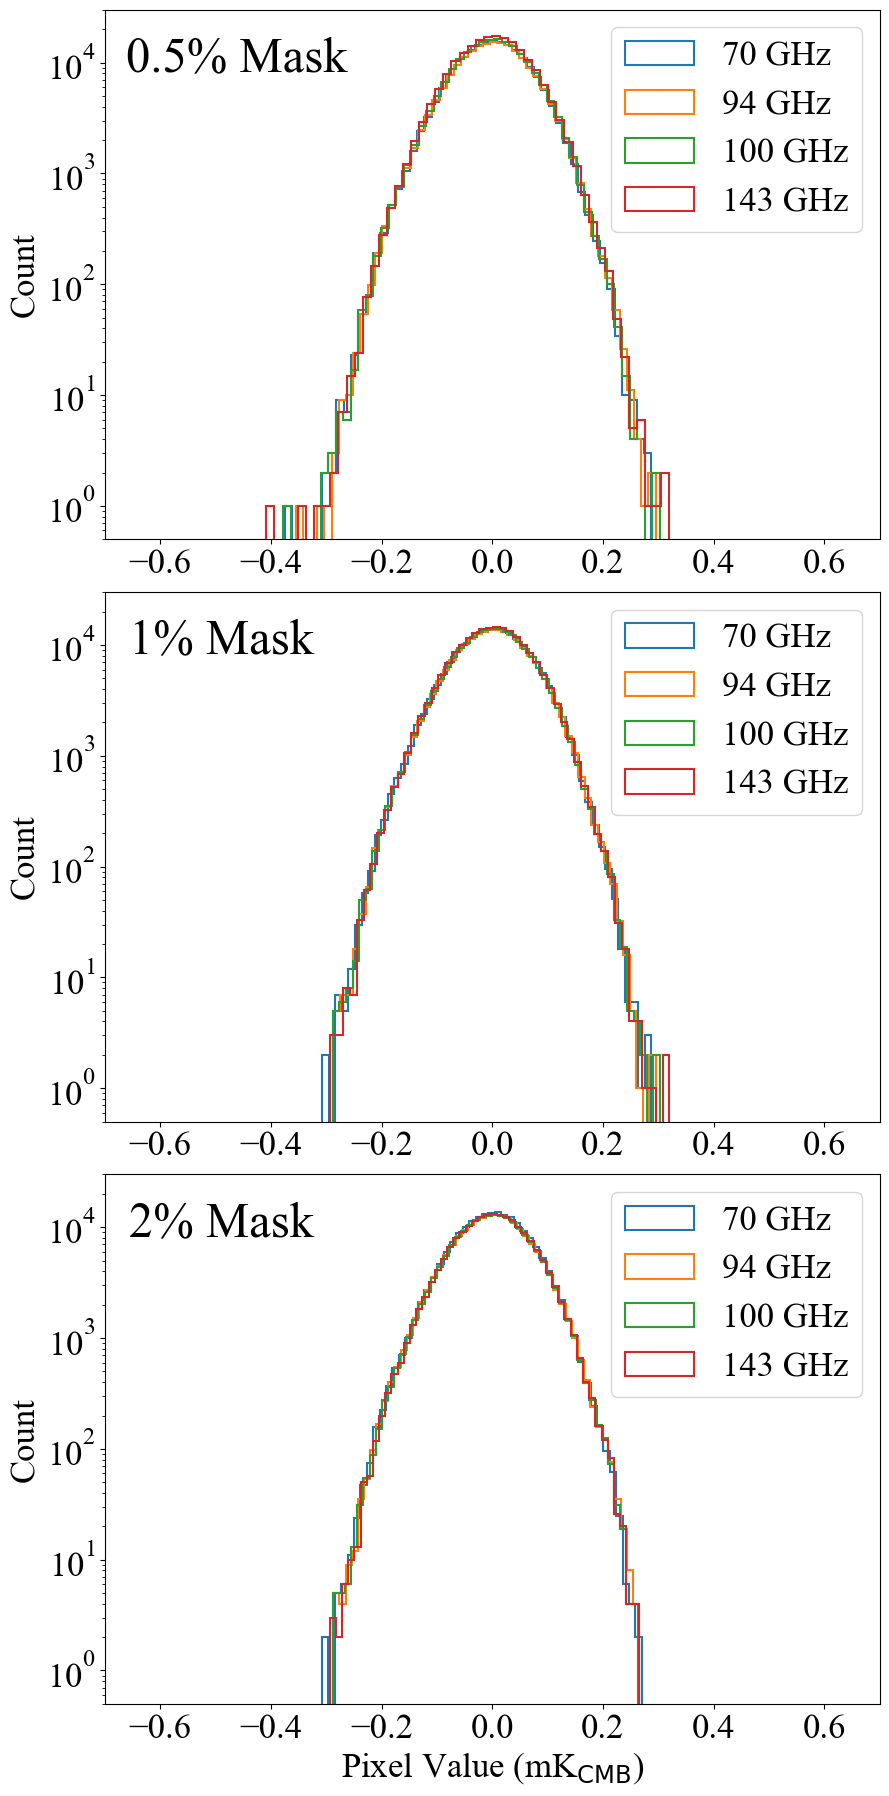

In [8]:
plt.rcParams.update({'font.size': 25}) 
plt.rcParams['font.family'] = 'Times New Roman'

fig, axe = plt.subplots(3, 1, figsize=(10, 22))
plt.subplots_adjust(hspace = 0.1)
# 0.5 percent mask
axe[0].hist(p70_mask05p, histtype='step', label = '70 GHz', bins = 50, alpha=1, linewidth=1.5)
axe[0].hist(w94_mask05p, histtype='step', label = '94 GHz', bins = 50, alpha=1, linewidth=1.5)
axe[0].hist(p100_mask05p, histtype='step', label = '100 GHz', bins = 50, alpha=1, linewidth=1.5)
axe[0].hist(p143_mask05p, histtype='step', label = '143 GHz', bins = 50, alpha=1 , linewidth=1.5)
axe[0].text(0.17, 0.95, '0.5% Mask', transform=axe[0].transAxes, fontsize=35, verticalalignment='top', horizontalalignment='center')
axe[0].set_ylabel('Count')
axe[0].legend(loc='upper right')
axe[0].set_xlim(-0.7,0.7)
axe[0].set_yscale('log')
axe[0].set_ylim(0.5,3e4)

# 1 percent mask
axe[1].hist(p70_mask1p,histtype='step', label = '70 GHz', bins = 50, alpha=1 , linewidth=1.5)
axe[1].hist(w94_mask1p, histtype='step', label = '94 GHz', bins = 50, alpha=1 , linewidth=1.5)
axe[1].hist(p100_mask1p, histtype='step', label = '100 GHz', bins = 50, alpha=1 , linewidth=1.5)
axe[1].hist(p143_mask1p, histtype='step', label = '143 GHz', bins = 50, alpha=1 , linewidth=1.5)
axe[1].text(0.15, 0.95, '1% Mask', transform=axe[1].transAxes, fontsize=35, verticalalignment='top', horizontalalignment='center')
axe[1].set_ylabel('Count')
axe[1].legend(loc='upper right')
axe[1].set_xlim(-0.7,0.7)
axe[1].set_yscale('log')
axe[1].set_ylim(0.5,3e4)

# 2 percent mask
axe[2].hist(p70_mask2p, histtype='step', label = '70 GHz', bins = 50, alpha=1 , linewidth=1.5)
axe[2].hist(w94_mask2p,  histtype='step', label = '94 GHz', bins = 50, alpha=1 , linewidth=1.5)
axe[2].hist(p100_mask2p,  histtype='step', label = '100 GHz', bins = 50, alpha=1 , linewidth=1.5)
axe[2].hist(p143_mask2p, histtype='step', label = '143 GHz', bins = 50, alpha=1 , linewidth=1.5)
axe[2].text(0.15, 0.95, '2% Mask', transform=axe[2].transAxes, fontsize=35, verticalalignment='top', horizontalalignment='center')
axe[2].set_xlabel(r'Pixel Value (mK$_{\rm CMB}$)')
axe[2].set_ylabel('Count')
axe[2].legend(loc='upper right')
axe[2].set_xlim(-0.7,0.7)
axe[2].set_yscale('log')
axe[2].set_ylim(0.5,3e4)

plt.show()